# 🏏 IPL Cricket Analytics — CodeAlpha Data Analytics Internship

**Name:** Your Name
**Internship:** CodeAlpha — Data Analytics
**GitHub Repo:** `CodeAlpha_IPLAnalytics`
**Dataset:** IPL Complete Dataset 2008–2020 (Kaggle)

---

| Task | Description |
|------|-------------|
| ✅ Task 1 | **Data Collection** — Load & inspect Kaggle IPL dataset |
| ✅ Task 2 | **EDA** — Trends, patterns, correlations |
| ✅ Task 3 | **Data Visualization** — Charts & dashboard |
| ✅ Task 4 | **Sentiment Analysis** — IPL news headlines |

---

## ⚙️ Install & Import Libraries

In [2]:
!pip install textblob vaderSentiment --quiet
!python -m textblob.download_corpora --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.4 MB/s eta 0:00:00
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, re, time, requests
from bs4 import BeautifulSoup
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)
print('✅ All libraries ready!')

✅ All libraries ready!


---
# 📂 TASK 1: Data Collection & Loading

In [4]:
from google.colab import files
print("Please upload matches.csv and deliveries.csv")
uploaded = files.upload()

Please upload matches.csv and deliveries.csv


Saving deliveries.csv to deliveries.csv
Saving matches.csv to matches.csv


In [5]:
import io

matches_df    = pd.read_csv(io.BytesIO(uploaded['matches.csv']))
deliveries_df = pd.read_csv(io.BytesIO(uploaded['deliveries.csv']))

print(f'matches.csv    — Shape: {matches_df.shape}')
print(f'deliveries.csv — Shape: {deliveries_df.shape}')

# ── SHOW EXACT COLUMN NAMES so we know what we're working with ──
print()
print('── matches.csv columns ──')
print(list(matches_df.columns))
print()
print('── deliveries.csv columns ──')
print(list(deliveries_df.columns))

matches.csv    — Shape: (1095, 20)
deliveries.csv — Shape: (260920, 17)

── matches.csv columns ──
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

── deliveries.csv columns ──
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [26]:

m_cols = matches_df.columns.str.lower().str.strip().tolist()
d_cols = deliveries_df.columns.str.lower().str.strip().tolist()

matches_df.columns = matches_df.columns.str.lower().str.strip()
deliveries_df.columns = deliveries_df.columns.str.lower().str.strip()

BAT_COL = 'batter' if 'batter' in deliveries_df.columns else 'batsman'

if 'season' not in matches_df.columns and 'date' in matches_df.columns:
    matches_df['season'] = pd.to_datetime(matches_df['date']).dt.year

WIN_COL = 'winner' if 'winner' in matches_df.columns else 'match_winner'

TOSS_WIN_COL    = 'toss_winner'
TOSS_DEC_COL    = 'toss_decision'

BAT_RUNS_COL = 'batsman_runs' if 'batsman_runs' in deliveries_df.columns else 'runs_off_bat'

TOTAL_RUNS_COL = 'total_runs' if 'total_runs' in deliveries_df.columns else 'runs_off_bat'

DISMISSAL_COL = 'dismissal_kind' if 'dismissal_kind' in deliveries_df.columns else 'wicket_type'

BOWL_COL = 'bowler'

print('Column mapping resolved:')
print(f'  Batsman col     : {BAT_COL}')
print(f'  Batsman runs    : {BAT_RUNS_COL}')
print(f'  Total runs      : {TOTAL_RUNS_COL}')
print(f'  Dismissal kind  : {DISMISSAL_COL}')
print(f'  Season col      : season')
print(f'  Winner col      : {WIN_COL}')
print()
print('Sample deliveries row:')
display(deliveries_df.head(3))

Column mapping resolved:
  Batsman col     : batter
  Batsman runs    : batsman_runs
  Total runs      : total_runs
  Dismissal kind  : dismissal_kind
  Season col      : season
  Winner col      : winner

Sample deliveries row:


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


In [8]:
print('Sample matches row:')
display(matches_df.head(3))

Sample matches row:


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [9]:

print('Missing Values — Matches:')
mv = matches_df.isnull().sum()
print(mv[mv>0].to_string() if mv.any() else '  None')

print()
print('Missing Values — Deliveries:')
mv2 = deliveries_df.isnull().sum()
print(mv2[mv2>0].to_string() if mv2.any() else '  None')

Missing Values — Matches:
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074

Missing Values — Deliveries:
extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566


In [10]:
matches_df.to_csv('ipl_matches_clean.csv', index=False)
deliveries_df.to_csv('ipl_deliveries_clean.csv', index=False)
print('✅ Task 1 Complete!')

✅ Task 1 Complete!


---
# 🔍 TASK 2: Exploratory Data Analysis (EDA)

In [11]:
print('='*55)
print('  DATASET OVERVIEW')
print('='*55)
print(f'Total Matches   : {len(matches_df)}')
print(f'Seasons         : {sorted(matches_df["season"].unique())}')
print(f'Total Teams     : {matches_df["team1"].nunique()}')
print(f'Total Venues    : {matches_df["venue"].nunique()}')
print(f'Total Deliveries: {len(deliveries_df):,}')
print(f'Total Batsmen   : {deliveries_df[BAT_COL].nunique()}')
print(f'Total Bowlers   : {deliveries_df[BOWL_COL].nunique()}')

  DATASET OVERVIEW
Total Matches   : 1095
Seasons         : ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
Total Teams     : 19
Total Venues    : 58
Total Deliveries: 260,920
Total Batsmen   : 673
Total Bowlers   : 530


In [12]:

matches_per_season = matches_df.groupby('season').size().reset_index(name='matches')
print('── Matches per Season ──')
display(matches_per_season)

── Matches per Season ──


,season,matches
0,2007/08,58
1,2009,57
2,2009/10,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


In [13]:

matches_df['toss_match_win'] = matches_df[TOSS_WIN_COL] == matches_df[WIN_COL]
toss_pct = matches_df['toss_match_win'].mean() * 100
print(f'Toss winner also won the match: {toss_pct:.1f}% of the time')
print()
print('Toss Decision preference:')
print(matches_df[TOSS_DEC_COL].value_counts().to_string())

Toss winner also won the match: 50.6% of the time

Toss Decision preference:
toss_decision
field    704
bat      391


In [27]:

batsman_runs = deliveries_df.groupby(BAT_COL)[BAT_RUNS_COL].sum().reset_index()
batsman_runs.columns = ['Batsman', 'Total_Runs']
batsman_runs = batsman_runs.sort_values('Total_Runs', ascending=False).reset_index(drop=True)
batsman_runs.index += 1
print('── Top 15 Run Scorers ──')
display(batsman_runs.head(15))

── Top 15 Run Scorers ──


,Batsman,Total_Runs
1,V Kohli,8014
2,S Dhawan,6769
3,RG Sharma,6630
4,DA Warner,6567
5,SK Raina,5536
6,MS Dhoni,5243
7,AB de Villiers,5181
8,CH Gayle,4997
9,RV Uthappa,4954
10,KD Karthik,4843


In [28]:

wicket_types = ['caught','bowled','lbw','stumped','caught and bowled','hit wicket']
bowler_wickets = deliveries_df[
    deliveries_df[DISMISSAL_COL].isin(wicket_types)
].groupby(BOWL_COL).size().reset_index(name='Wickets')
bowler_wickets = bowler_wickets.sort_values('Wickets', ascending=False).reset_index(drop=True)
bowler_wickets.index += 1
print('── Top 15 Wicket Takers ──')
display(bowler_wickets.head(15))

── Top 15 Wicket Takers ──


,bowler,Wickets
1,YS Chahal,205
2,PP Chawla,192
3,DJ Bravo,183
4,B Kumar,181
5,R Ashwin,180
6,SP Narine,180
7,A Mishra,174
8,SL Malinga,170
9,JJ Bumrah,168
10,RA Jadeja,160


In [29]:

bat_stats = deliveries_df.groupby(BAT_COL).agg(
    Runs   = (BAT_RUNS_COL, 'sum'),
    Balls  = (BAT_RUNS_COL, 'count'),
    Fours  = (BAT_RUNS_COL, lambda x: (x==4).sum()),
    Sixes  = (BAT_RUNS_COL, lambda x: (x==6).sum()),
).reset_index()
bat_stats.rename(columns={BAT_COL:'batsman'}, inplace=True)
bat_stats['StrikeRate'] = (bat_stats['Runs'] / bat_stats['Balls'] * 100).round(2)
bat_stats = bat_stats[bat_stats['Runs'] >= 500].sort_values('Runs', ascending=False).reset_index(drop=True)
print(f'Batsmen with 500+ runs: {len(bat_stats)}')
display(bat_stats.head(10))

Batsmen with 500+ runs: 149


,batsman,Runs,Balls,Fours,Sixes,StrikeRate
0,V Kohli,8014,6236,708,273,128.51
1,S Dhawan,6769,5483,768,153,123.45
2,RG Sharma,6630,5183,599,281,127.92
3,DA Warner,6567,4849,663,236,135.43
4,SK Raina,5536,4177,506,204,132.54
5,MS Dhoni,5243,3947,363,252,132.84
6,AB de Villiers,5181,3487,414,253,148.58
7,CH Gayle,4997,3516,408,359,142.12
8,RV Uthappa,4954,3927,481,182,126.15
9,KD Karthik,4843,3687,466,161,131.35


In [30]:

bowl_stats = deliveries_df.groupby(BOWL_COL).agg(
    Runs  = (TOTAL_RUNS_COL, 'sum'),
    Balls = (TOTAL_RUNS_COL, 'count'),
).reset_index()
bowl_stats['Overs']   = bowl_stats['Balls'] / 6
bowl_stats['Economy'] = (bowl_stats['Runs'] / bowl_stats['Overs']).round(2)
bowl_stats = bowl_stats[bowl_stats['Overs']>=50].sort_values('Economy').reset_index(drop=True)
print('── Most Economical Bowlers (min 50 overs) ──')
display(bowl_stats.head(10))

── Most Economical Bowlers (min 50 overs) ──


,bowler,Runs,Balls,Overs,Economy
0,A Kumble,1089,983,163.833333,6.65
1,GD McGrath,366,329,54.833333,6.67
2,M Muralitharan,1765,1581,263.500000,6.70
3,J Yadav,447,398,66.333333,6.74
4,SP Narine,4672,4146,691.000000,6.76
5,DW Steyn,2583,2282,380.333333,6.79
6,RE van der Merwe,515,455,75.833333,6.79
7,DL Vettori,894,785,130.833333,6.83
8,Rashid Khan,3340,2901,483.500000,6.91
9,J Botha,818,709,118.166667,6.92


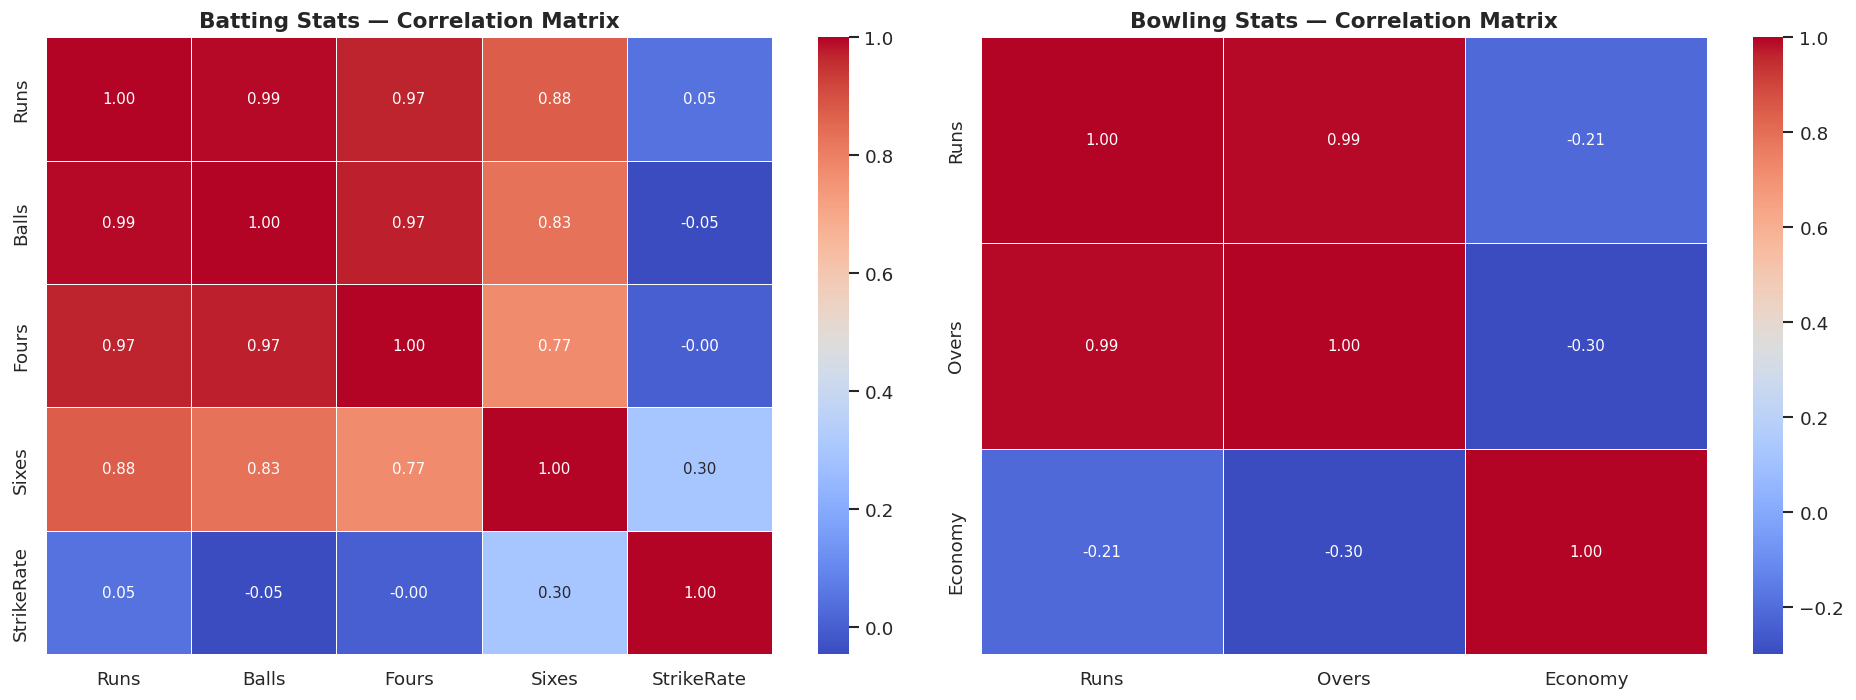

In [31]:

fig, axes = plt.subplots(1,2,figsize=(16,6))
bat_corr = bat_stats[['Runs','Balls','Fours','Sixes','StrikeRate']].corr()
sns.heatmap(bat_corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], linewidths=0.5, annot_kws={'size':9})
axes[0].set_title('Batting Stats — Correlation Matrix', fontsize=13, fontweight='bold')

bowl_corr = bowl_stats[['Runs','Overs','Economy']].corr()
sns.heatmap(bowl_corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5, annot_kws={'size':9})
axes[1].set_title('Bowling Stats — Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

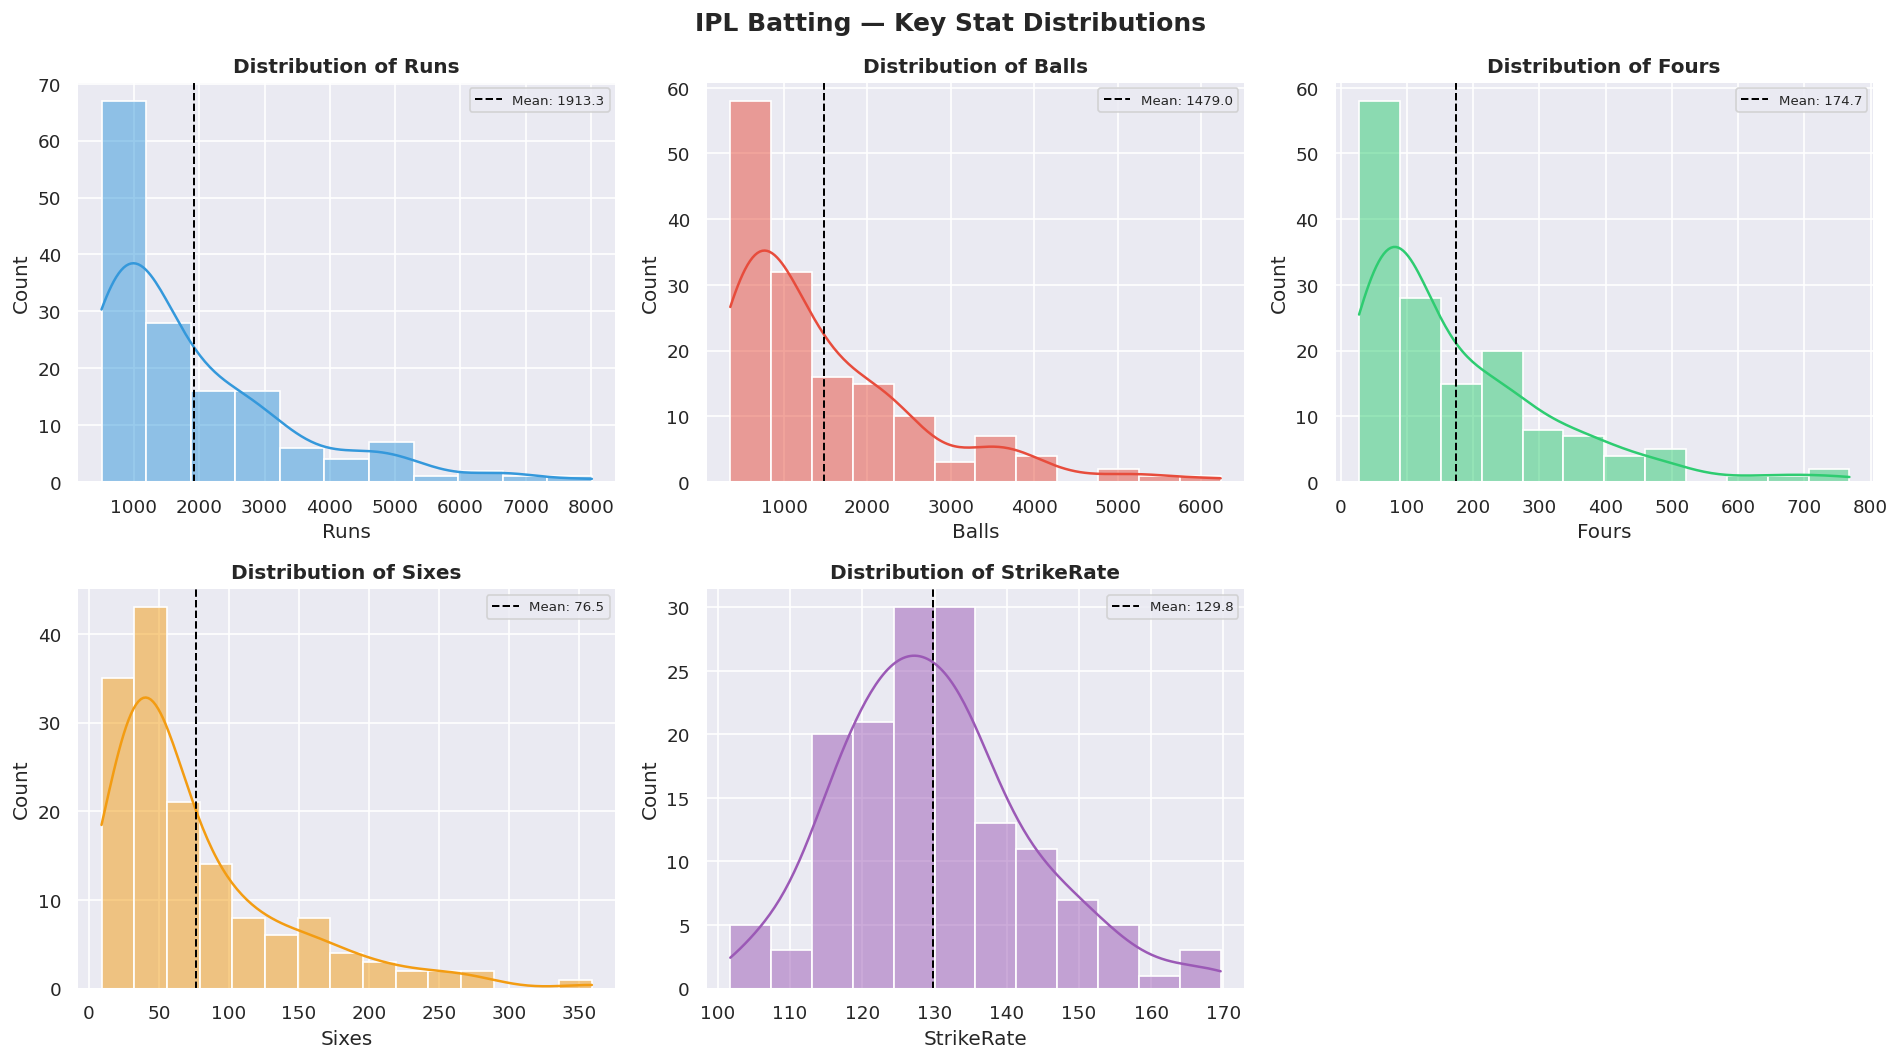

In [32]:

fig, axes = plt.subplots(2,3,figsize=(16,9))
fig.suptitle('IPL Batting — Key Stat Distributions', fontsize=15, fontweight='bold')
cols   = ['Runs','Balls','Fours','Sixes','StrikeRate']
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']
for ax, col, color in zip(axes.flatten(), cols, colors):
    sns.histplot(bat_stats[col], kde=True, ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.axvline(bat_stats[col].mean(), color='black', ls='--', lw=1.2,
               label=f"Mean: {bat_stats[col].mean():.1f}")
    ax.legend(fontsize=8)
axes[1,2].set_visible(False)
plt.tight_layout(); plt.show()

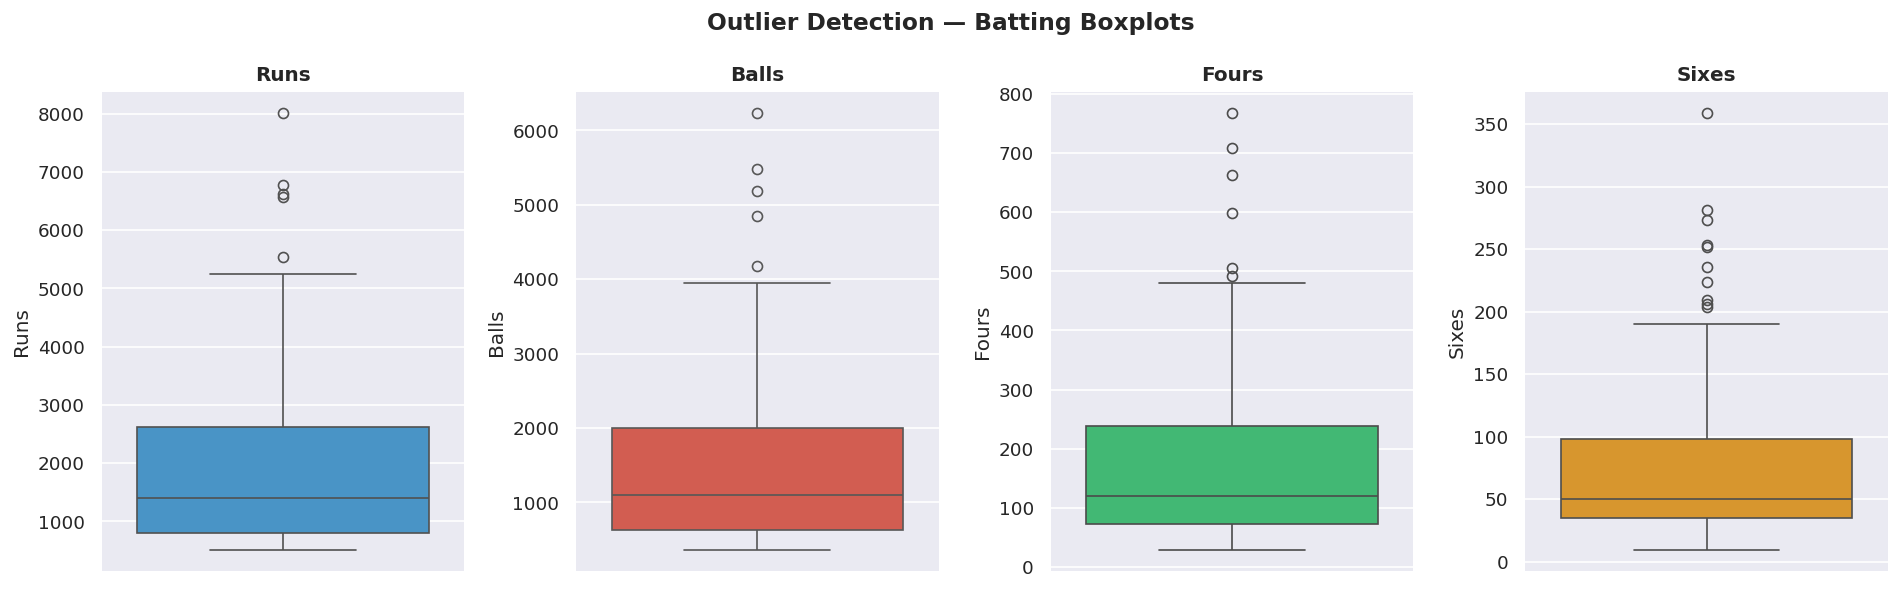

In [33]:

fig, axes = plt.subplots(1,4,figsize=(16,5))
fig.suptitle('Outlier Detection — Batting Boxplots', fontsize=14, fontweight='bold')
for ax, col, color in zip(axes, ['Runs','Balls','Fours','Sixes'],
                           ['#3498db','#e74c3c','#2ecc71','#f39c12']):
    sns.boxplot(y=bat_stats[col], ax=ax, color=color)
    ax.set_title(col, fontweight='bold')
plt.tight_layout(); plt.show()

In [34]:

print('📊 HYPOTHESIS TESTING')
print('='*55)
c1 = bat_stats[['Runs','StrikeRate']].corr().iloc[0,1]
print(f'H1: More Runs = Higher Strike Rate?  Corr: {c1:.3f}')
print(f'   → {"Positive: consistent high-scorers also hit aggressively" if c1>0 else "Negative: big run-getters pace themselves"}')

c2 = bat_stats[['Runs','Sixes']].corr().iloc[0,1]
print(f'H2: More Runs = More Sixes?  Corr: {c2:.3f}')
print(f'   → {"Strong: six-hitters accumulate big totals" if c2>0.6 else "Moderate relationship"}')

toss_pct = matches_df['toss_match_win'].mean()*100
print(f'H3: Does winning toss help win match?')
print(f'   Toss winner won {toss_pct:.1f}% of matches')
print(f'   → {"Slight advantage" if toss_pct>52 else "Almost no advantage — toss is mostly luck!"}')

📊 HYPOTHESIS TESTING
H1: More Runs = Higher Strike Rate?  Corr: 0.047
   → Positive: consistent high-scorers also hit aggressively
H2: More Runs = More Sixes?  Corr: 0.877
   → Strong: six-hitters accumulate big totals
H3: Does winning toss help win match?
   Toss winner won 50.6% of matches
   → Almost no advantage — toss is mostly luck!


---
# 📊 TASK 3: Data Visualization

In [35]:
IPL_COLORS = ['#004BA0','#FF6B00','#1C1C1C','#00A651','#FF0000','#7B2D8B','#FFCC00','#0078BC','#F26522','#009CDE','#C8102E','#D4AF37']

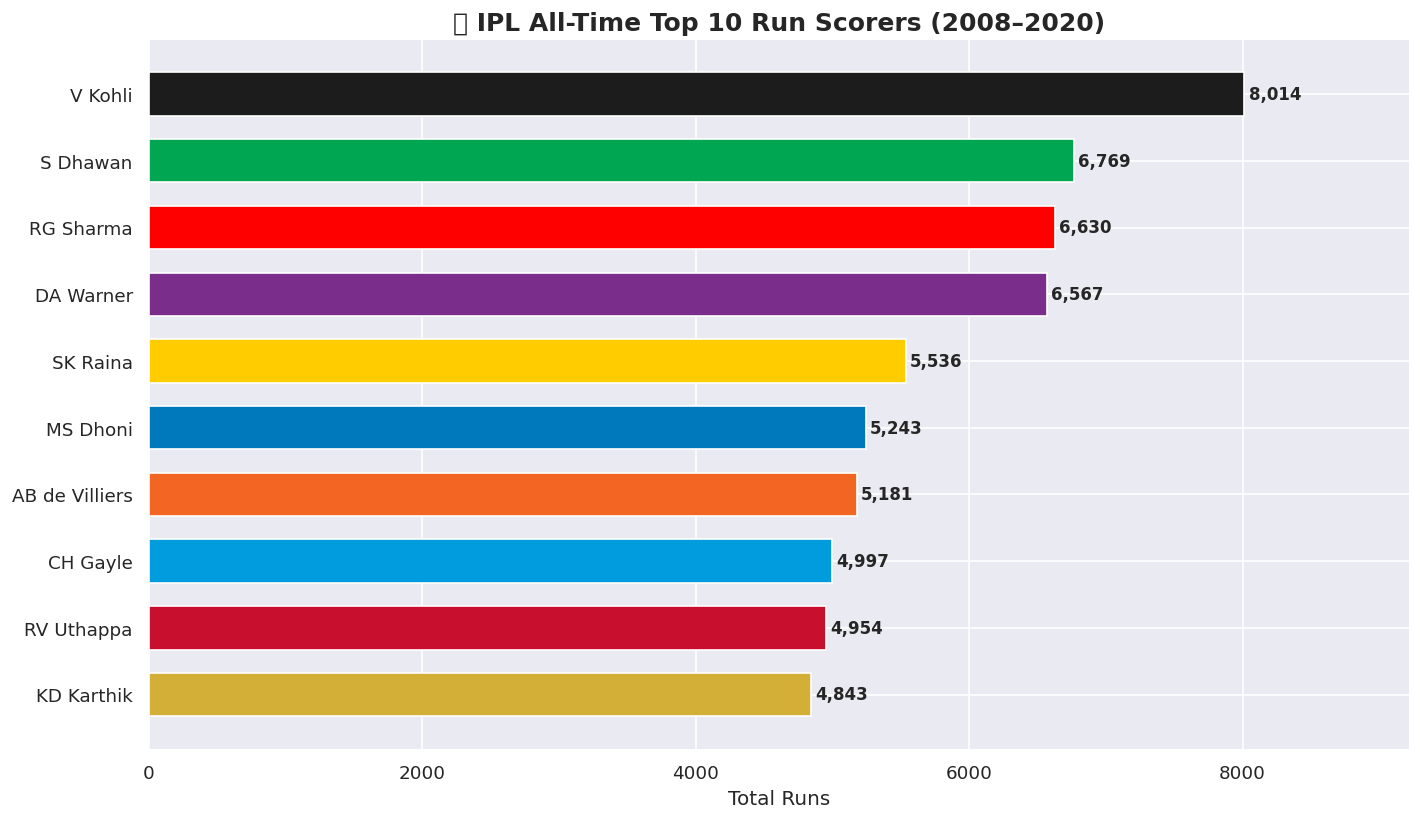

In [36]:

top10_bat = batsman_runs.head(10).sort_values('Total_Runs')
fig, ax = plt.subplots(figsize=(12,7))
bars = ax.barh(top10_bat['Batsman'], top10_bat['Total_Runs'],
               color=IPL_COLORS[::-1], edgecolor='white', height=0.65)
for bar, val in zip(bars, top10_bat['Total_Runs']):
    ax.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
            f'{int(val):,}', va='center', ha='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Total Runs', fontsize=12)
ax.set_title('🏏 IPL All-Time Top 10 Run Scorers (2008–2020)', fontsize=15, fontweight='bold')
ax.set_xlim(0, top10_bat['Total_Runs'].max()*1.15)
sns.despine(left=True, bottom=True)
plt.tight_layout(); plt.show()

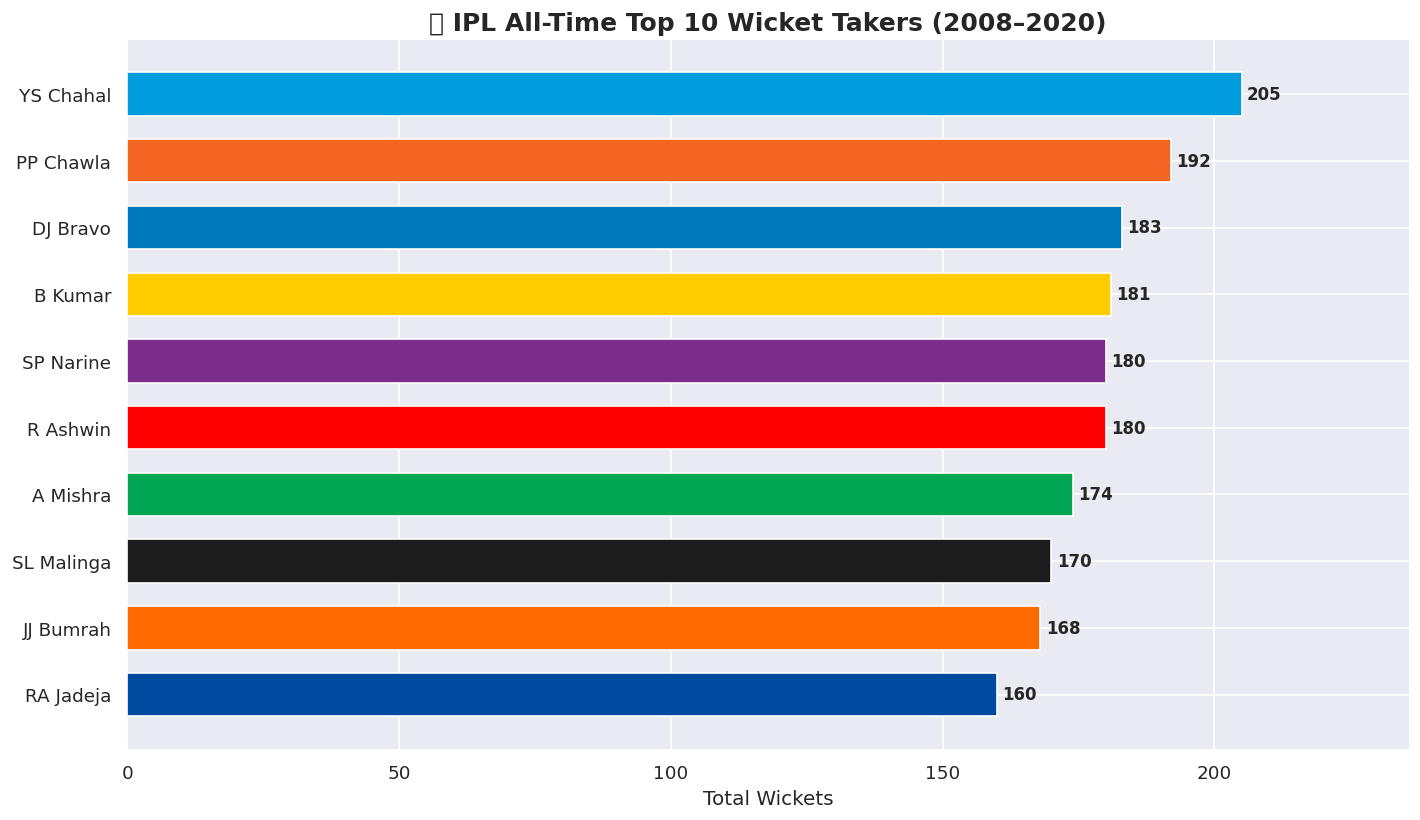

In [37]:

top10_bowl = bowler_wickets.head(10).sort_values('Wickets')
fig, ax = plt.subplots(figsize=(12,7))
bars = ax.barh(top10_bowl[BOWL_COL], top10_bowl['Wickets'],
               color=IPL_COLORS, edgecolor='white', height=0.65)
for bar, val in zip(bars, top10_bowl['Wickets']):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            str(int(val)), va='center', ha='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Total Wickets', fontsize=12)
ax.set_title('🎳 IPL All-Time Top 10 Wicket Takers (2008–2020)', fontsize=15, fontweight='bold')
ax.set_xlim(0, top10_bowl['Wickets'].max()*1.15)
sns.despine(left=True, bottom=True)
plt.tight_layout(); plt.show()

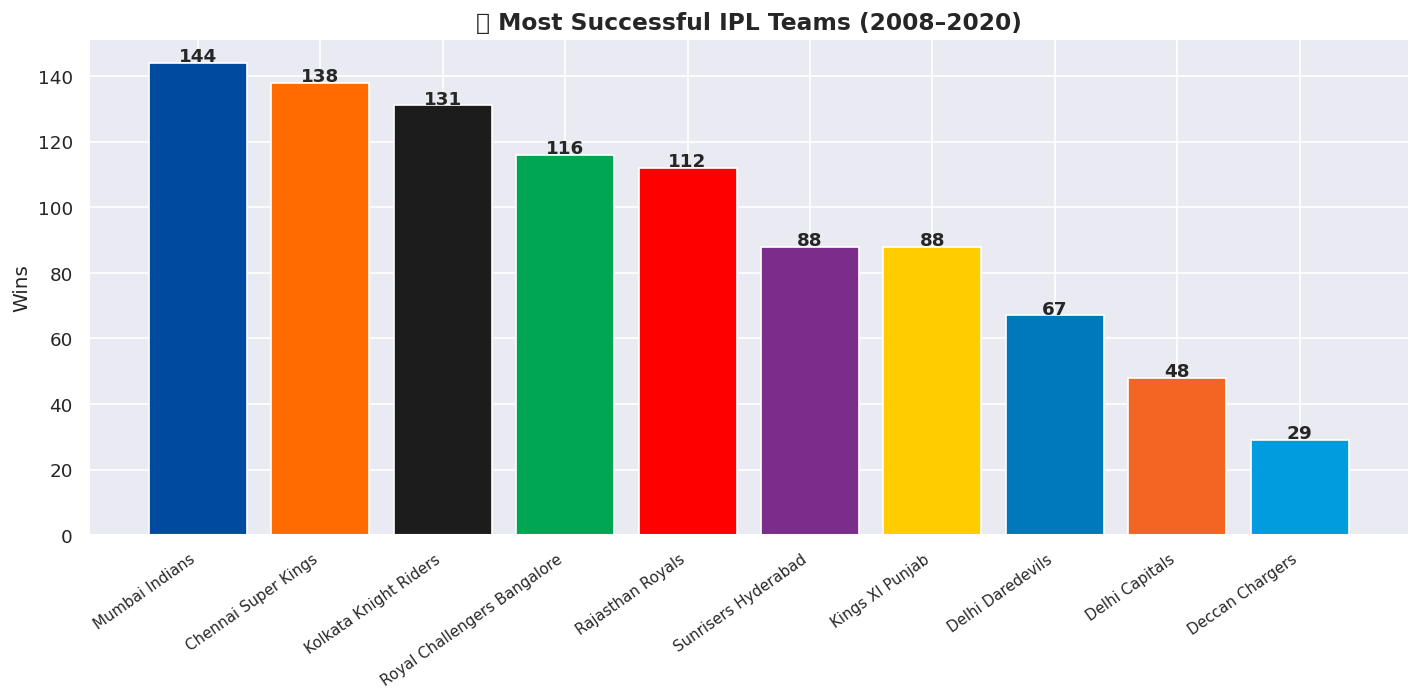

In [38]:

team_wins_plot = matches_df[WIN_COL].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12,6))
bars = ax.bar(team_wins_plot.index, team_wins_plot.values,
              color=IPL_COLORS[:len(team_wins_plot)], edgecolor='white')
for bar, val in zip(bars, team_wins_plot.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            str(val), ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Wins', fontsize=12)
ax.set_title('🏆 Most Successful IPL Teams (2008–2020)', fontsize=14, fontweight='bold')
ax.set_xticklabels(team_wins_plot.index, rotation=35, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

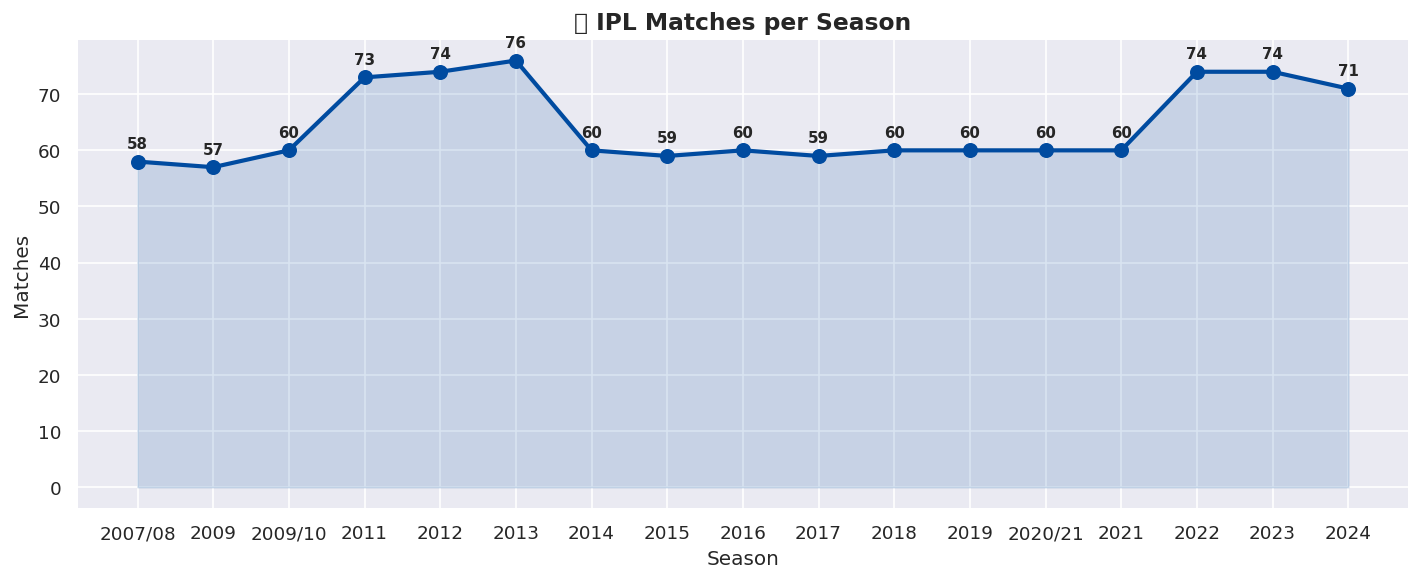

In [39]:

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(matches_per_season['season'], matches_per_season['matches'],
        marker='o', linewidth=2.5, markersize=8, color='#004BA0')
ax.fill_between(matches_per_season['season'], matches_per_season['matches'],
                alpha=0.15, color='#004BA0')
for _, row in matches_per_season.iterrows():
    ax.annotate(str(int(row['matches'])), (row['season'], row['matches']),
                textcoords='offset points', xytext=(0,8),
                ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Matches', fontsize=12)
ax.set_title('📅 IPL Matches per Season', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

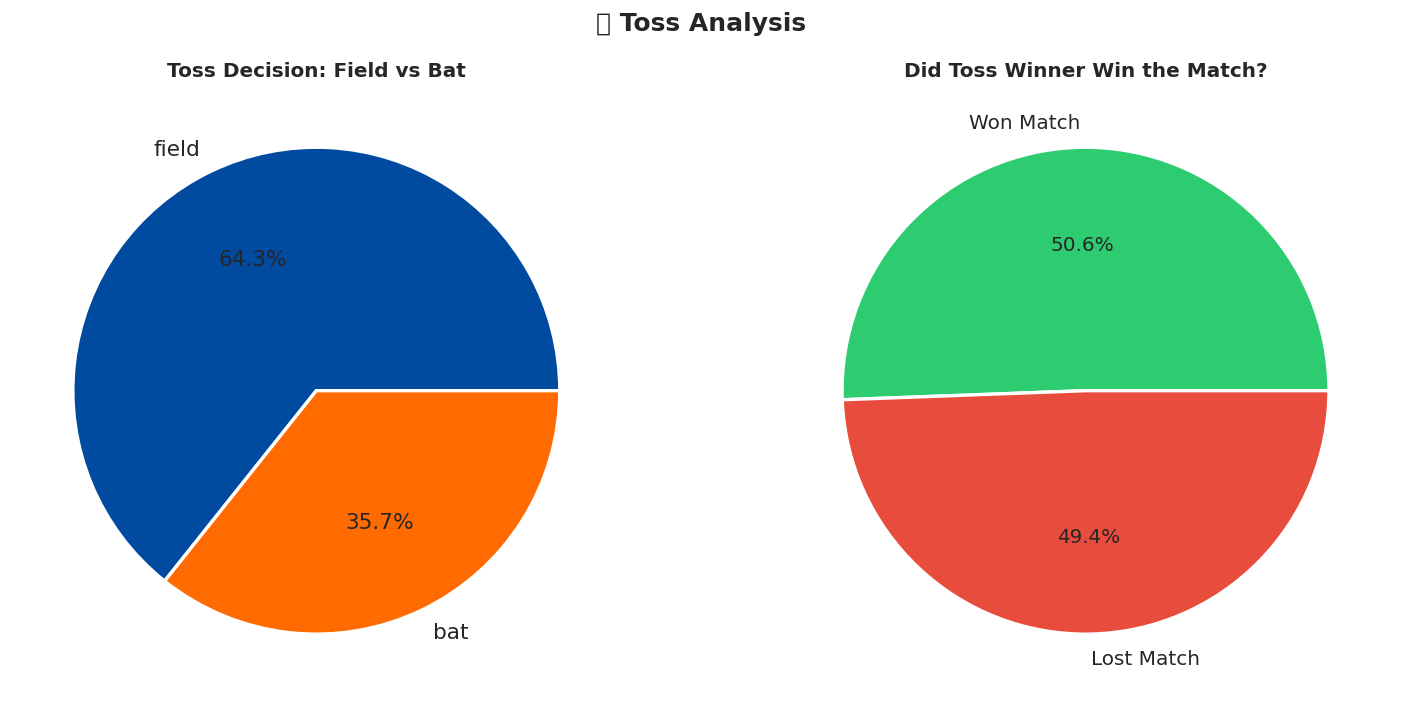

In [40]:

fig, axes = plt.subplots(1,2,figsize=(13,6))
fig.suptitle('🪙 Toss Analysis', fontsize=15, fontweight='bold')
td = matches_df[TOSS_DEC_COL].value_counts()
axes[0].pie(td.values, labels=td.index, autopct='%1.1f%%',
            colors=['#004BA0','#FF6B00'],
            wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':13})
axes[0].set_title('Toss Decision: Field vs Bat', fontweight='bold')
tv = matches_df['toss_match_win'].value_counts()
axes[1].pie(tv.values, labels=['Won Match','Lost Match'], autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'],
            wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':12})
axes[1].set_title('Did Toss Winner Win the Match?', fontweight='bold')
plt.tight_layout(); plt.show()

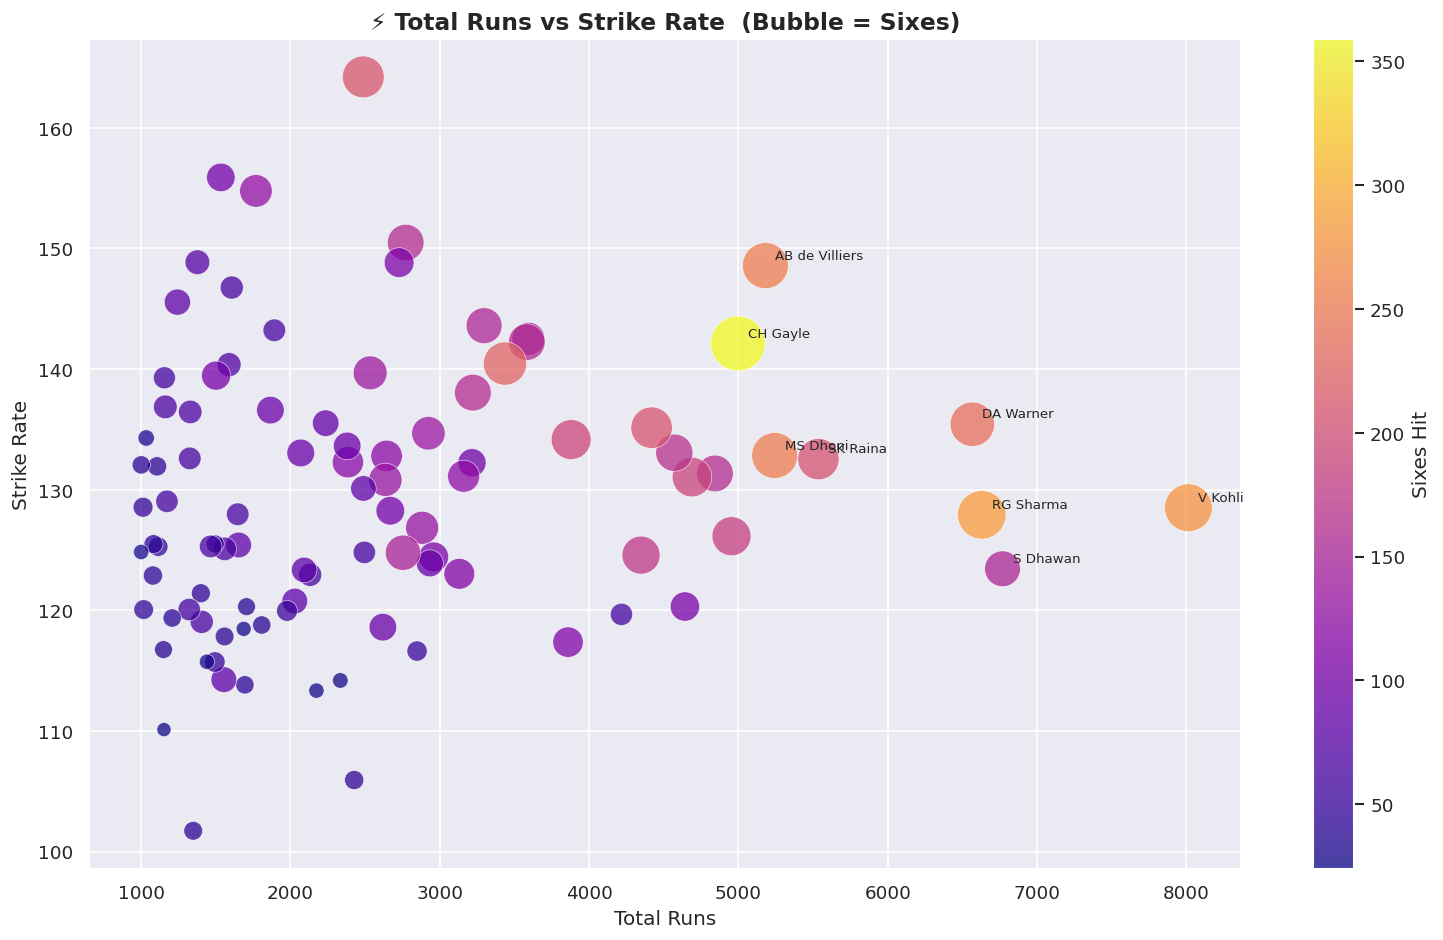

In [41]:

bat_plot = bat_stats[bat_stats['Runs']>=1000].copy()
fig, ax = plt.subplots(figsize=(13,8))
sc = ax.scatter(bat_plot['Runs'], bat_plot['StrikeRate'],
                s=bat_plot['Sixes']*3, c=bat_plot['Sixes'],
                cmap='plasma', alpha=0.75, edgecolors='white', linewidth=0.4)
plt.colorbar(sc, ax=ax, label='Sixes Hit')
for _, row in bat_plot.nlargest(8,'Runs').iterrows():
    ax.annotate(row['batsman'], (row['Runs'], row['StrikeRate']),
                fontsize=8, xytext=(6,4), textcoords='offset points')
ax.set_xlabel('Total Runs', fontsize=12)
ax.set_ylabel('Strike Rate', fontsize=12)
ax.set_title('⚡ Total Runs vs Strike Rate  (Bubble = Sixes)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

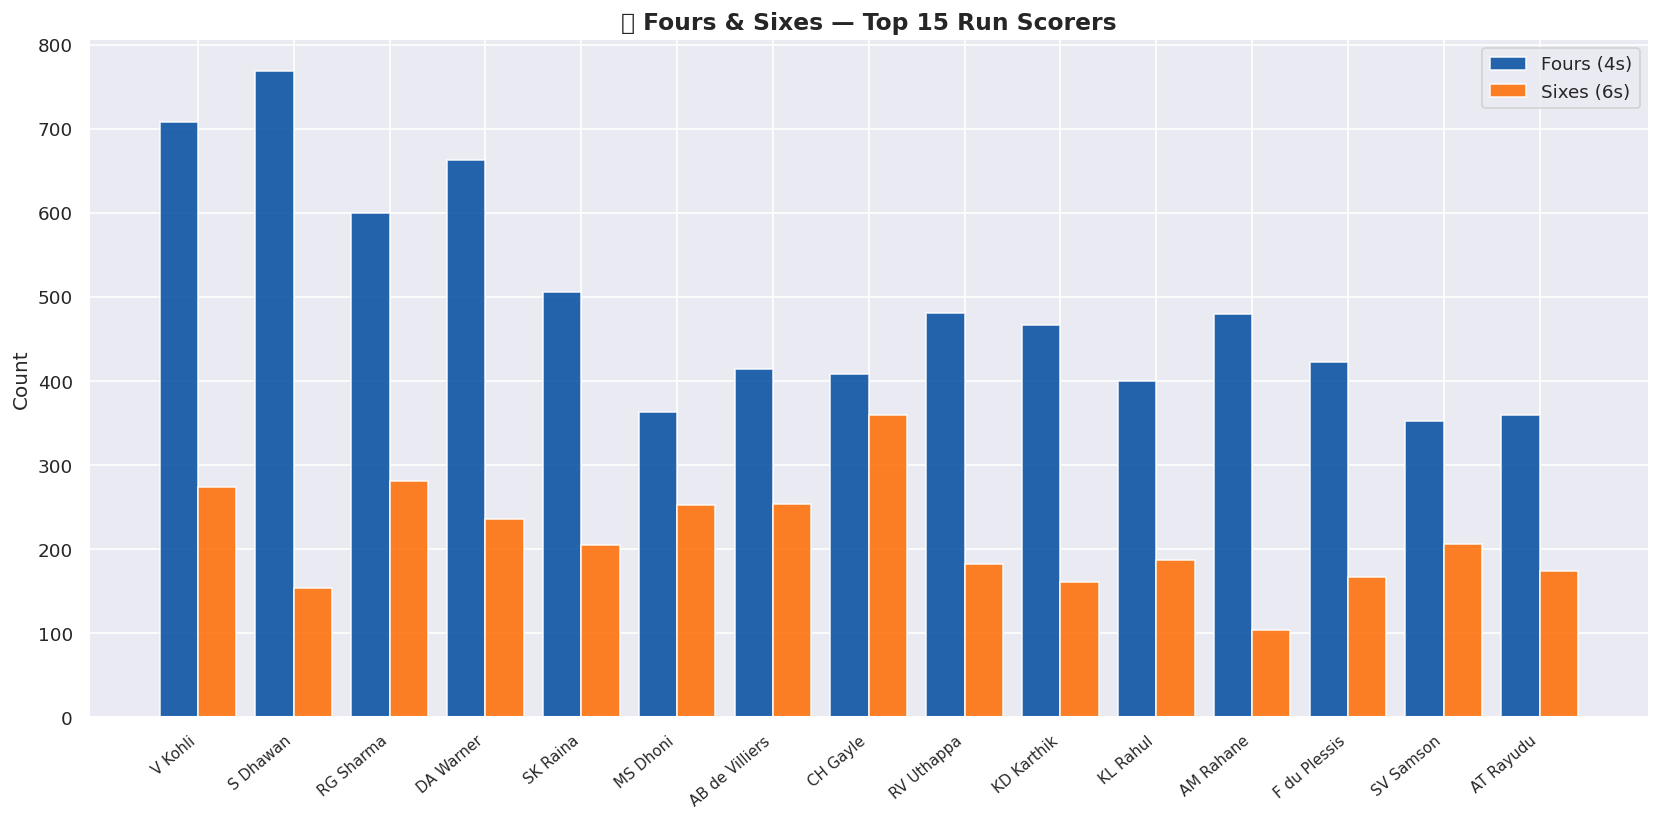

In [42]:

top15 = bat_stats.nlargest(15,'Runs').copy()
x = np.arange(len(top15))
fig, ax = plt.subplots(figsize=(14,7))
ax.bar(x-0.2, top15['Fours'], 0.4, label='Fours (4s)', color='#004BA0', alpha=0.85)
ax.bar(x+0.2, top15['Sixes'], 0.4, label='Sixes (6s)', color='#FF6B00', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top15['batsman'], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('🏏 Fours & Sixes — Top 15 Run Scorers', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

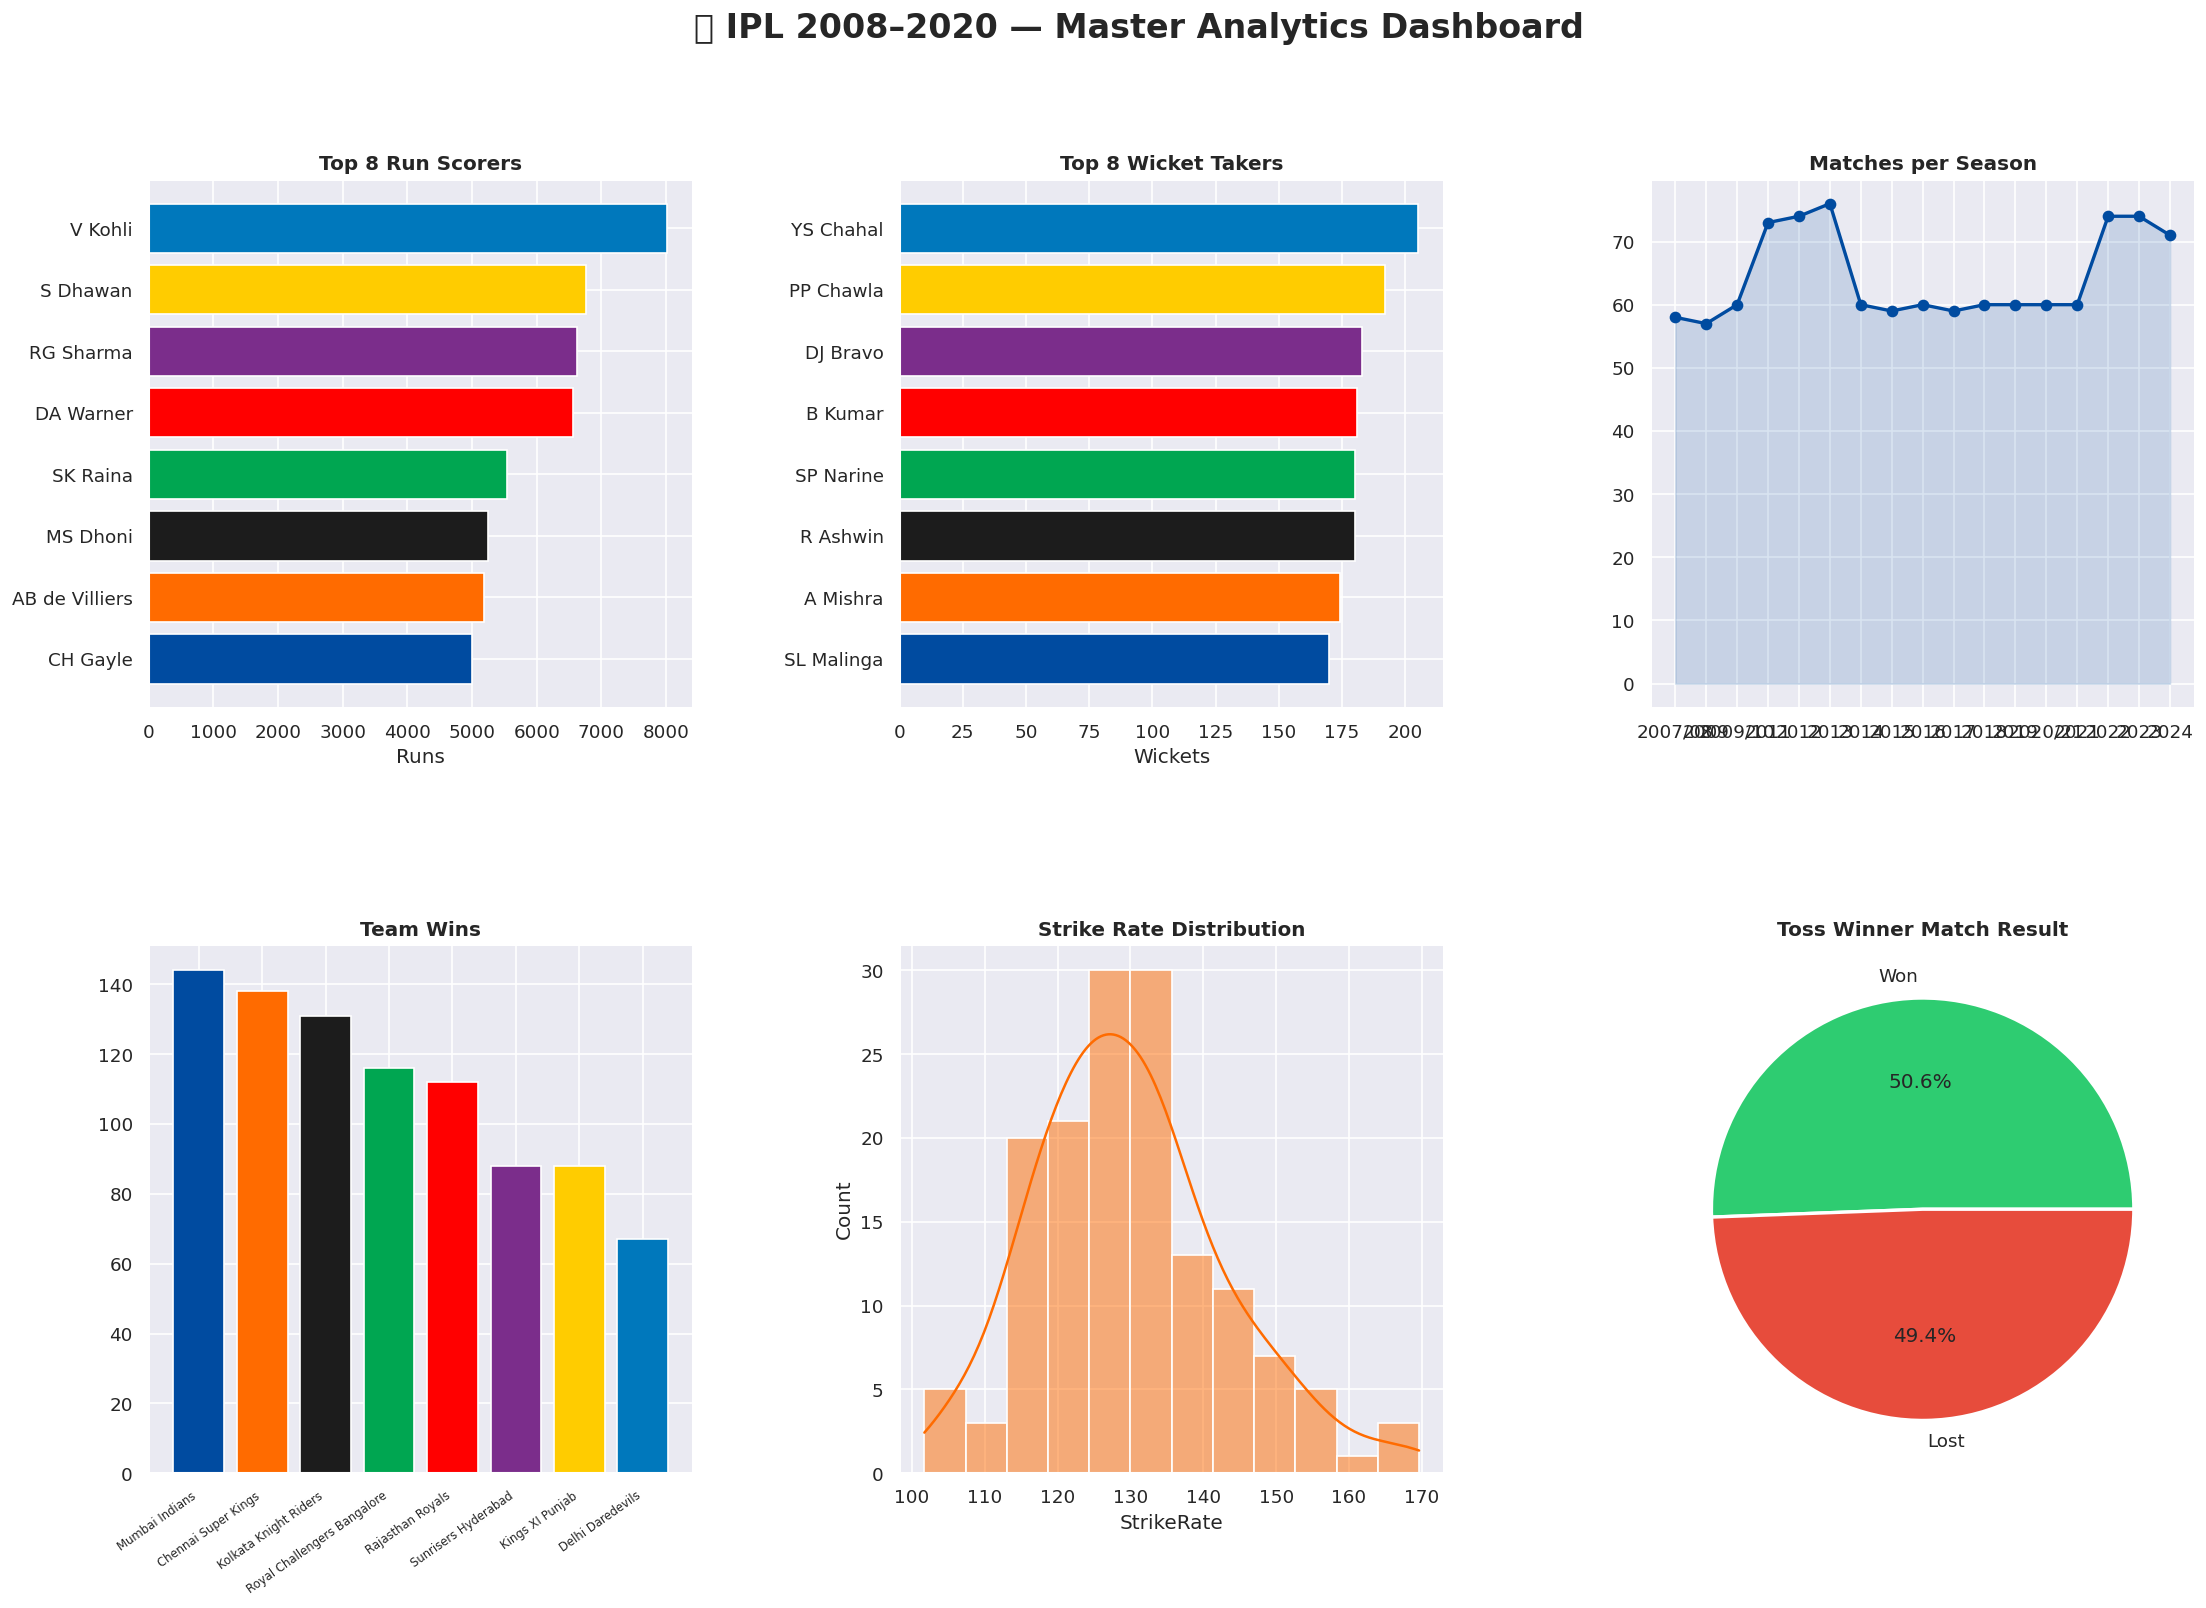

✅ Dashboard saved!


In [43]:

fig = plt.figure(figsize=(22,14))
fig.suptitle('🏏 IPL 2008–2020 — Master Analytics Dashboard', fontsize=20, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2,3,figure=fig,hspace=0.45,wspace=0.38)

ax1=fig.add_subplot(gs[0,0]); t=batsman_runs.head(8).sort_values('Total_Runs')
ax1.barh(t['Batsman'],t['Total_Runs'],color=IPL_COLORS[:8])
ax1.set_title('Top 8 Run Scorers',fontweight='bold'); ax1.set_xlabel('Runs')

ax2=fig.add_subplot(gs[0,1]); t2=bowler_wickets.head(8).sort_values('Wickets')
ax2.barh(t2[BOWL_COL],t2['Wickets'],color=IPL_COLORS[:8])
ax2.set_title('Top 8 Wicket Takers',fontweight='bold'); ax2.set_xlabel('Wickets')

ax3=fig.add_subplot(gs[0,2])
ax3.plot(matches_per_season['season'],matches_per_season['matches'],marker='o',color='#004BA0',lw=2)
ax3.fill_between(matches_per_season['season'],matches_per_season['matches'],alpha=0.15,color='#004BA0')
ax3.set_title('Matches per Season',fontweight='bold')

ax4=fig.add_subplot(gs[1,0]); tw=matches_df[WIN_COL].value_counts().head(8)
ax4.bar(range(len(tw)),tw.values,color=IPL_COLORS[:8],edgecolor='white')
ax4.set_xticks(range(len(tw))); ax4.set_xticklabels(tw.index,rotation=35,ha='right',fontsize=7)
ax4.set_title('Team Wins',fontweight='bold')

ax5=fig.add_subplot(gs[1,1])
sns.histplot(bat_stats['StrikeRate'],kde=True,ax=ax5,color='#FF6B00')
ax5.set_title('Strike Rate Distribution',fontweight='bold')

ax6=fig.add_subplot(gs[1,2]); tv=matches_df['toss_match_win'].value_counts()
ax6.pie(tv.values,labels=['Won','Lost'],autopct='%1.1f%%',
        colors=['#2ecc71','#e74c3c'],wedgeprops={'edgecolor':'white','linewidth':2})
ax6.set_title('Toss Winner Match Result',fontweight='bold')

plt.savefig('ipl_dashboard.png',dpi=150,bbox_inches='tight')
plt.show(); print('✅ Dashboard saved!')

---
# 💬 TASK 4: Sentiment Analysis

In [44]:
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0'}
vader_analyzer = SentimentIntensityAnalyzer()

def scrape_news(query):
    url = 'https://news.google.com/rss/search?q=' + query.replace(' ','+') + '&hl=en-IN&gl=IN&ceid=IN:en'
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        soup = BeautifulSoup(resp.content, 'xml')
        return [{'headline': item.find('title').get_text(strip=True)}
                for item in soup.find_all('item') if item.find('title')]
    except Exception as e:
        print(f'Error: {e}'); return []

print('Scraping IPL news...')
all_news = []
for q in ['IPL 2024','IPL cricket match','Indian Premier League','IPL player']:
    r = scrape_news(q); all_news.extend(r)
    print(f'  {q}: {len(r)} headlines'); time.sleep(1)

news_df = pd.DataFrame(all_news).drop_duplicates(subset='headline').reset_index(drop=True)
print(f'Total unique headlines: {len(news_df)}')

if len(news_df) == 0:
    print('Using sample headlines for demo...')
    samples = [
        'Virat Kohli smashes century as RCB crush MI in thrilling contest',
        'MS Dhoni stunning finish seals victory for Chennai Super Kings',
        'IPL controversy as umpire makes horrible decision in crucial match',
        'Rohit Sharma disappoints with early dismissal in crunch game',
        'Jasprit Bumrah incredible five-wicket haul destroys opposition',
        'Rain ruins match, fans left frustrated and angry at organizers',
        'Punjab Kings pull off incredible chase, crowd goes absolutely wild',
        'Rajasthan Royals batting collapses badly as bowlers dominate',
        'KL Rahul masterclass innings guides Lucknow to comfortable win',
        'Young talent shines in debut match, future looks very bright',
        'DRS controversy sparks heated debate among cricket fans online',
        'Kolkata Knight Riders celebrate historic win in dramatic finale',
        'Delhi Capitals suffer embarrassing defeat against strong opposition',
        'Sunrisers Hyderabad edge close contest in nail-biting finish',
        'Poor pitch conditions draw heavy criticism from players',
        'Mumbai Indians stunning comeback as they beat title favorites',
        'IPL auction excitement with record-breaking player bids',
        'Terrible fielding errors cost team crucial points in tight contest',
        'Brilliant bowling restricts opponents to very low total score',
        'Fans disappointed as match ends with no result due to weather',
    ]
    news_df = pd.DataFrame({'headline': samples})
display(news_df.head())

Scraping IPL news...
  IPL 2024: 100 headlines
  IPL cricket match: 100 headlines
  Indian Premier League: 104 headlines
  IPL player: 100 headlines
Total unique headlines: 380


,headline
0,IPL 2026 captains: Know the 10 skippers - full...
1,KKR's fast bowling problem: 2024 winners head ...
2,Anil Kumble Slams KKR For Releasing Star Duo A...
3,‘KKR took the wrong decision by letting Shreya...
4,KKR unveil new jersey ahead of IPL 2026 season...


In [45]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    return re.sub(r'\s+', ' ', text).strip()

news_df['clean'] = news_df['headline'].apply(clean_text)
news_df['tb_polarity']     = news_df['clean'].apply(lambda x: TextBlob(x).sentiment.polarity)
news_df['tb_subjectivity'] = news_df['clean'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
news_df['vader_compound']  = news_df['clean'].apply(lambda x: vader_analyzer.polarity_scores(x)['compound'])
news_df['vader_pos']       = news_df['clean'].apply(lambda x: vader_analyzer.polarity_scores(x)['pos'])
news_df['vader_neg']       = news_df['clean'].apply(lambda x: vader_analyzer.polarity_scores(x)['neg'])
news_df['vader_neu']       = news_df['clean'].apply(lambda x: vader_analyzer.polarity_scores(x)['neu'])
news_df['sentiment']       = news_df['vader_compound'].apply(
    lambda c: 'Positive' if c>=0.05 else ('Negative' if c<=-0.05 else 'Neutral'))

print('✅ Sentiment Analysis Complete!')
print(news_df['sentiment'].value_counts().to_string())
display(news_df[['headline','vader_compound','tb_polarity','sentiment']].head(10))

✅ Sentiment Analysis Complete!
sentiment
Neutral     187
Positive    141
Negative     52


,headline,vader_compound,tb_polarity,sentiment
0,IPL 2026 captains: Know the 10 skippers - full...,0.0000,0.350000,Neutral
1,KKR's fast bowling problem: 2024 winners head ...,-0.1280,-0.066667,Negative
2,Anil Kumble Slams KKR For Releasing Star Duo A...,-0.4767,-0.500000,Negative
3,‘KKR took the wrong decision by letting Shreya...,-0.4767,-0.500000,Negative
4,KKR unveil new jersey ahead of IPL 2026 season...,0.0000,0.136364,Neutral
5,IPL 2024: Harbhajan Singh urges Rohit Sharma t...,0.0000,0.000000,Neutral
6,IPL 2026: Three Fast Bowlers Who Could Replace...,-0.4019,0.200000,Negative
7,Who Can Replace Harshit Rana at KKR for IPL 20...,0.0000,0.000000,Neutral
8,"Days Ahead Of IPL 2026, Anil Kumble Points Out...",-0.4767,-0.500000,Negative
9,SRH Playing XI For IPL 2026 (Predicted Lineup)...,0.2023,0.000000,Positive


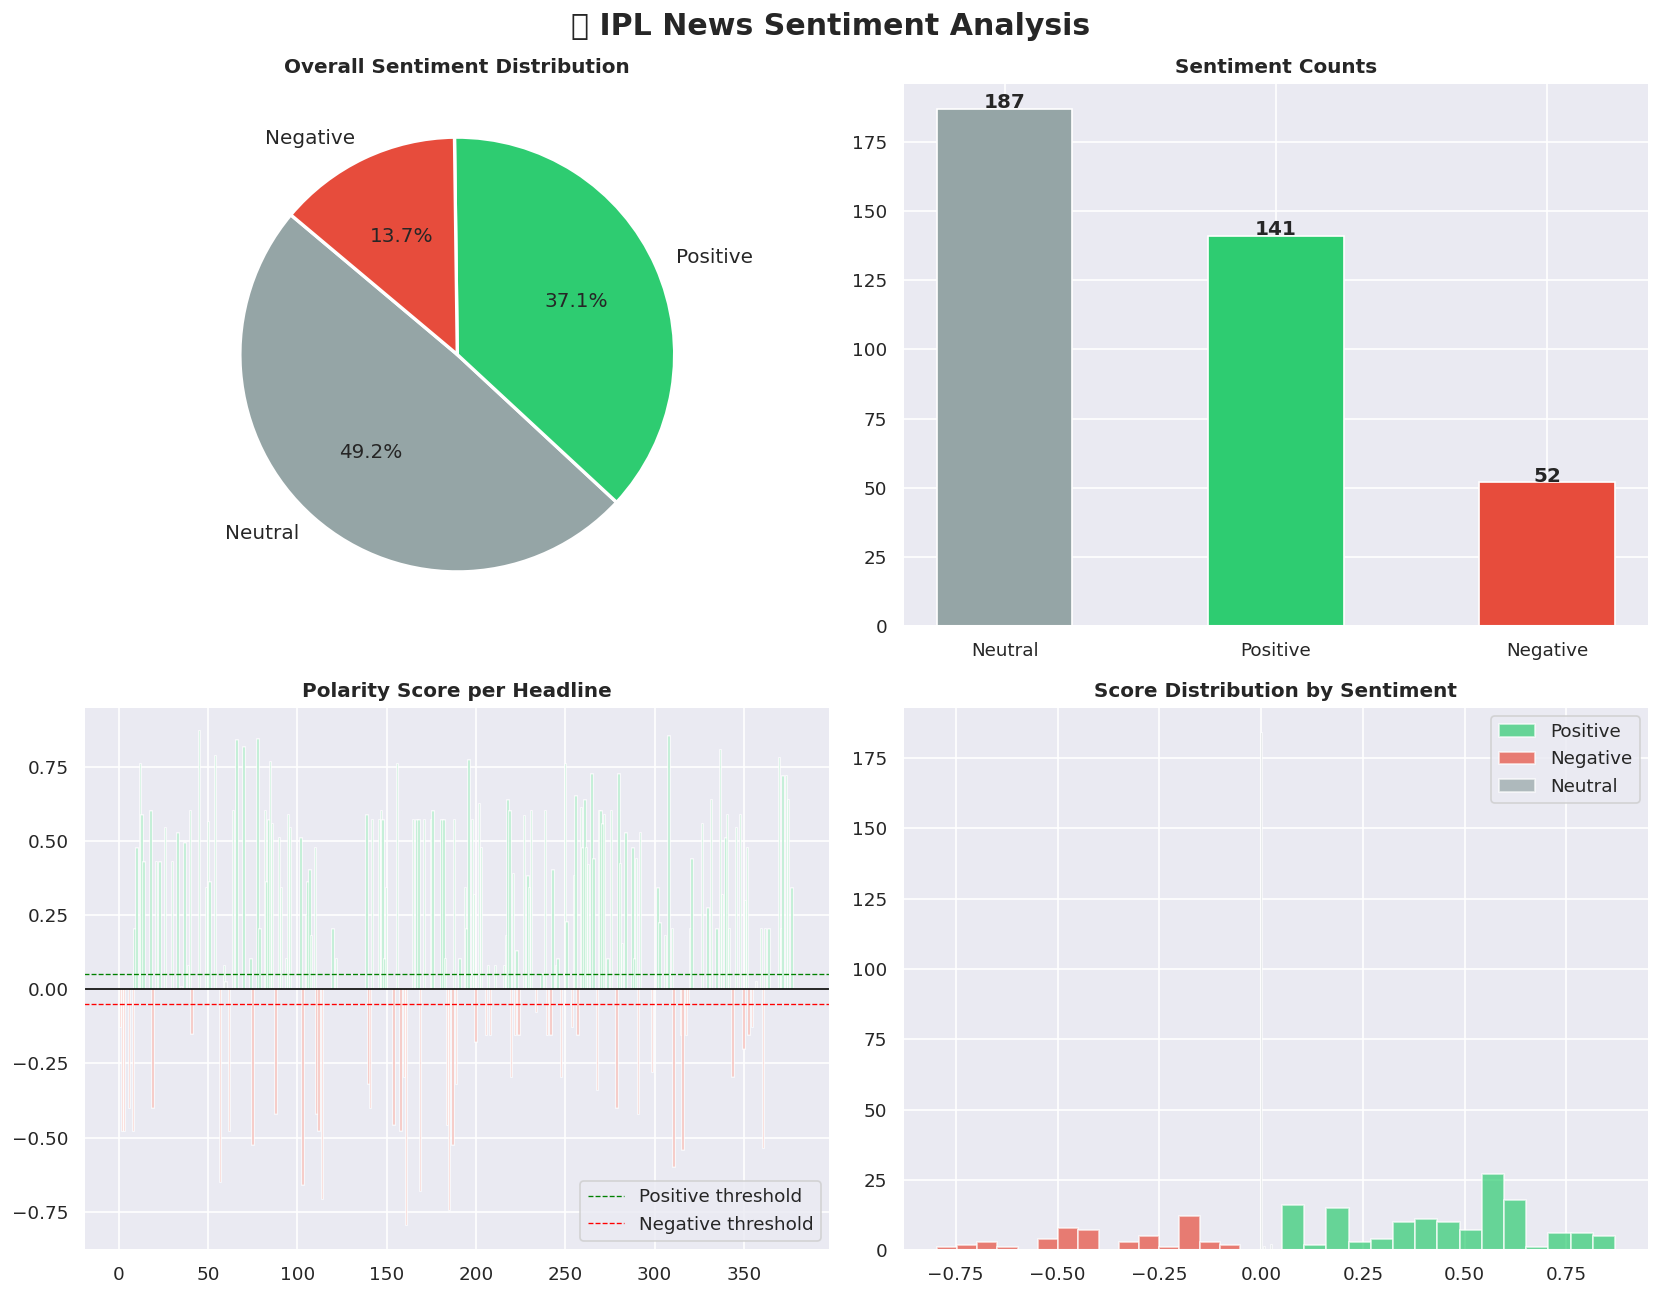

✅ Saved!


In [46]:
SENT_COLORS = {'Positive':'#2ecc71','Negative':'#e74c3c','Neutral':'#95a5a6'}
counts = news_df['sentiment'].value_counts()

fig, axes = plt.subplots(2,2,figsize=(14,11))
fig.suptitle('💬 IPL News Sentiment Analysis', fontsize=18, fontweight='bold')

colors_pie = [SENT_COLORS.get(l,'#999') for l in counts.index]
axes[0,0].pie(counts.values, labels=counts.index, colors=colors_pie, autopct='%1.1f%%',
              startangle=140, wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':12})
axes[0,0].set_title('Overall Sentiment Distribution', fontweight='bold')

axes[0,1].bar(counts.index, counts.values, color=colors_pie, edgecolor='white', width=0.5)
for i,(l,v) in enumerate(zip(counts.index, counts.values)):
    axes[0,1].text(i, v+0.2, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0,1].set_title('Sentiment Counts', fontweight='bold')

bar_c = [SENT_COLORS.get(s,'#999') for s in news_df['sentiment']]
axes[1,0].bar(range(len(news_df)), news_df['vader_compound'], color=bar_c, alpha=0.8)
axes[1,0].axhline(0, color='black', lw=1)
axes[1,0].axhline(0.05, color='green', ls='--', lw=0.8, label='Positive threshold')
axes[1,0].axhline(-0.05, color='red', ls='--', lw=0.8, label='Negative threshold')
axes[1,0].set_title('Polarity Score per Headline', fontweight='bold')
axes[1,0].legend()

for sent, color in SENT_COLORS.items():
    sub = news_df[news_df['sentiment']==sent]['vader_compound']
    if not sub.empty:
        axes[1,1].hist(sub, bins=15, color=color, alpha=0.7, label=sent, edgecolor='white')
axes[1,1].set_title('Score Distribution by Sentiment', fontweight='bold')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('ipl_sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Saved!')

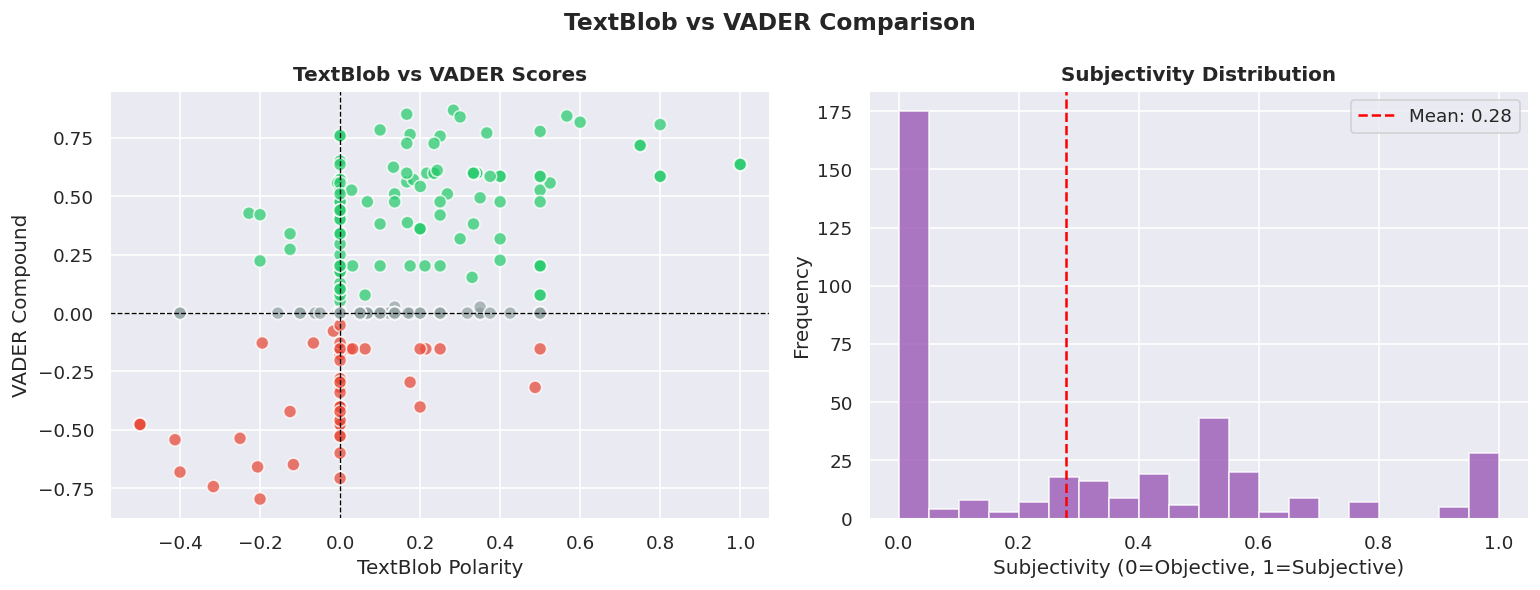

In [47]:

fig, axes = plt.subplots(1,2,figsize=(13,5))
fig.suptitle('TextBlob vs VADER Comparison', fontsize=14, fontweight='bold')
colors_map = {'Positive':'#2ecc71','Negative':'#e74c3c','Neutral':'#95a5a6'}
axes[0].scatter(news_df['tb_polarity'], news_df['vader_compound'],
                c=[colors_map.get(s,'grey') for s in news_df['sentiment']],
                alpha=0.75, s=60, edgecolors='white')
axes[0].axhline(0,color='black',lw=0.8,ls='--'); axes[0].axvline(0,color='black',lw=0.8,ls='--')
axes[0].set_xlabel('TextBlob Polarity'); axes[0].set_ylabel('VADER Compound')
axes[0].set_title('TextBlob vs VADER Scores', fontweight='bold')

axes[1].hist(news_df['tb_subjectivity'], bins=20, color='#9b59b6', alpha=0.8, edgecolor='white')
axes[1].axvline(news_df['tb_subjectivity'].mean(), color='red', ls='--', lw=1.5,
                label=f"Mean: {news_df['tb_subjectivity'].mean():.2f}")
axes[1].set_xlabel('Subjectivity (0=Objective, 1=Subjective)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Subjectivity Distribution', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

In [48]:
news_df.to_csv('ipl_sentiment_results.csv', index=False)
print('✅ Saved: ipl_sentiment_results.csv')
for sent in ['Positive','Negative','Neutral']:
    sub = news_df[news_df['sentiment']==sent]
    if not sub.empty:
        print(f'[{sent}] {sub.iloc[0]["headline"][:85]}...')

✅ Saved: ipl_sentiment_results.csv
[Positive] SRH Playing XI For IPL 2026 (Predicted Lineup) - durhamccc.co.uk...
[Negative] KKR's fast bowling problem: 2024 winners head towards shaky start to IPL campaign - I...
[Neutral] IPL 2026 captains: Know the 10 skippers - full list - olympics.com...


---
# ✅ Project Summary

| Task | Status | Key Outputs |
|------|--------|-------------|
| Task 1: Data Collection | ✅ Done | `ipl_matches_clean.csv`, `ipl_deliveries_clean.csv` |
| Task 2: EDA | ✅ Done | Stats, correlations, hypothesis tests, outlier detection |
| Task 3: Visualization | ✅ Done | 8 charts + `ipl_dashboard.png` |
| Task 4: Sentiment Analysis | ✅ Done | `ipl_sentiment_results.csv` + charts |

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · TextBlob · VADER · BeautifulSoup

**GitHub Repo:** `CodeAlpha_IPLAnalytics`

In [49]:
from google.colab import files

files.download('ipl_matches_clean.csv')
files.download('ipl_dashboard.png')
files.download('ipl_sentiment_analysis.png')
files.download('ipl_sentiment_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>